## Permission Modes & Human Gates

### **Claude Code Task Execution Phases**

- _Exploration Phase_: Claude Code reads files, traces logic, and builds an understanding of the codebase before writing anything.

- _Plan Phase_: It creates a structured description of proposed edits for your review and approval.

- _Code Phase_: It writes and executes changes only after you approve the plan.

### **Permission Modes & Scope**

- _default:_
    - Auto-approves: Read-only actions.
    - Gates: Prompts for confirmation before nearly every file edit or shell command.
    - Limitations: Safe, but slow on trusted work. Serves as the baseline for new projects or unfamiliar codebases.

- _acceptEdits:_
    - Auto-approves: Low-stakes, reversible edits (e.g., formatting fixes or changes confined within the working directory).
    - Gates: Actions outside the working directory or high-stakes commands.

- _plan:_
    - Scope: Holds Claude Code in the exploration phase, blocking all file edits and shell commands until you explicitly release it.

- _auto / dontAsk:_
    - Scope: Designed to reduce or eliminate manual confirmation prompts for standard actions during execution.

- _bypassPermissions:_
    - Scope: Auto-approves all tool calls with no confirmation prompts and removes protected-path guards (recommended strictly within isolated containers/VMs).

### **Configuration Hierarchy**

- _User Level (~/.claude/settings.json)_: Applies to every project on your machine.

- _Project Level (.claude/settings.json)_: Committed to the repository and applies to the whole team (team conventions, allow/deny rules).

- _Local Project Level (.claude/settings.local.json)_: Personal, git-ignored overrides for a single project.

- _Enterprise Level (managed-settings.json)_: Set by administrators and cannot be overridden by users or project files.

**Note: A deny rule always wins over an allow rule regardless of the active mode.**

### **Placing Human Review Gates**

- _Low-Stakes Actions_: Allow formatting fixes or working-directory edits through without a gate since the cost of being wrong is low.

- _Sensitive Actions_: Gate writes outside the working directory, destructive shell commands, or changes to security-relevant paths.

- _Sensitive Code_: Never let the agent be the sole gate on code your team marks as sensitive; a human must always review it before merging.

## Durable Project Context

### **CLAUDE.md: Global Project Memory**

- _Automatic Loading_: Every session automatically reads CLAUDE.md from the project root and prepends its contents to your prompt.

- _Content_: Best suited for universal project rules, build/test commands, framework conventions, and style guidelines.

- _Context Budget_: Keeping CLAUDE.md concise prevents rule dilution and avoids unnecessarily consuming the context window.

- _Generation_: The _/init_ command creates a starter _CLAUDE.md_ file by scanning your codebase, which should be reviewed and refined.

### **Rules Instruction Files: Targeted Guidance**

- _Location_: Stored inside the .claude/rules/ directory.

- _Path Scoping_: Can be configured with a paths glob in the YAML frontmatter so rules only load into context when Claude is working with matching files.

- _Unscoped Behavior_: Rules without a paths glob load unconditionally at session start, taking the same priority as CLAUDE.md.

### **Hooks: Enforced Lifecycle Automation**

Hooks run scripts automatically at specific lifecycle events, bypassing LLM discretion:

- _PreToolUse_: Fires before a tool runs. Can exit with code 2 to block tool execution (e.g., blocking edits to sensitive paths).

- _PostToolUse_: Fires after a tool completes. Used for automated side effects like running code formatters or triggering tests.

- _UserPromptSubmit_: Runs when you submit a prompt to inject context or validate requests before processing.

- _Stop_: Executes when the model completes its response, useful for cleanup or notifications.

- _SessionStart / SessionEnd_: Runs at startup or closure to initialize environments or handle teardowns.

### **Subagents: Context-Isolated Delegation**

- _Isolation_: Subagents execute tasks in separate contexts without inheriting the main session's conversation history.

- _Built-in Agents (Explore / Plan)_: Skip loading CLAUDE.md and git status to maximize execution speed.

- _Rule Compliance_: Tasks requiring project rules should use the general-purpose subagent or a custom subagent.

- _Custom Subagents_: Defined in .claude/agents. They do not automatically load skills unless explicitly declared in their frontmatter.

## MCP SERVERS

### **1. What is an MCP Server?**

- _Concept_: Model Context Protocol (MCP) separates tool definitions from individual applications into a standalone server process. Instead of writing custom integrations across multiple applications, you build the capability once on an MCP server so any connected MCP client (like Claude Code) can discover and invoke it.

**Exposed Elements:**

- Tools: Callable actions the model can invoke during a session.

- Resources: Read-only data exposed at direct or templated addresses. These are fetched directly into context when known data is needed upfront, serving as a cheaper and more predictable option than tool calls.

- Prompts: Pre-written instruction templates maintained on the server to ensure consistent response quality across clients.

### **2. Transport & Context Cost**
**Transports**:

- _stdio / HTTP:_ Modern supported transports for communication between client and server.

- _SSE (Server-Sent Events)_: Legacy transport method; superseded by HTTP and no longer recommended.

**Context Window Management:**

- By default, Claude Code defers tool definitions and uses a search step to load only relevant tools on demand.

- An opt-in mode loads definitions upfront if they fit within ~10% of the context window.

### **3. Prompt Caching & RAG**

- _Prompt Caching_: Avoids reprocessing identical context (e.g., system prompts or tool definitions) by setting up to four cache_control breakpoints.

    - Default lifetime is 5 minutes (resets on read).

    - An opt-in 1-hour ttl is available for agentic workflows with longer delays.

    - Applies only above a minimum threshold (1,024 tokens).

- _Retrieval-Augmented Generation (RAG):_

    - _Classical RAG_: Chunks documents, generates vector embeddings upfront, and retrieves top matching chunks from a database.

    - _Agentic Search_: Skips upfront indexing; the model dynamically searches and retrieves source materials at runtime based on immediate need.

### **4. Configuration Scopes :**

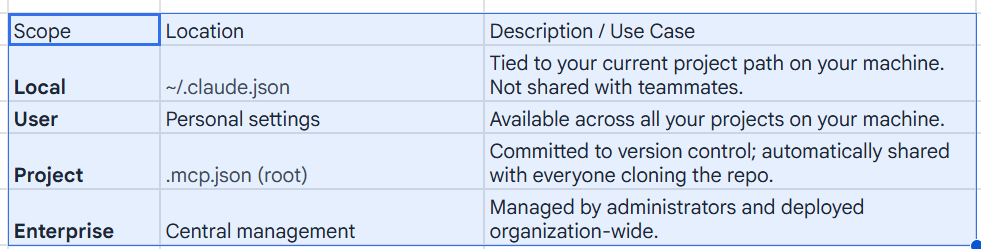

### **5. Permissions & Security**

- _Granular Permissions_: Tool rules can target specific tools on a server using the syntax mcp__<server>__<tool> (e.g., mcp__github__create_issue). Deny rules override allow rules.

- _API MCP Connector_: Uses an enabled flag inside an mcp_toolset object to control whether the model even sees specific tools.

- Authentication Examples:

    - GitHub MCP Server: Uses HTTP transport with a Personal Access Token supplied as an environment variable (never hardcode tokens into .mcp.json).

    - Linear MCP Server: Uses OAuth browser sign-in flows for user identity verification.

**Implementation Example: Anthropic Messages API Prompt Caching**

While the page covers the theoretical concepts above, below is how you configure Prompt Caching in Python using the Anthropic API. Notice how cache_control is attached directly to the tool definitions block:

In [ ]:
import anthropic

client = anthropic.Anthropic()

response = client.messages.create(
    model="claude-3-5-sonnet-20241022",
    max_tokens=1000,
    # System prompt can also be cached
    system=[
        {
            "type": "text",
            "text": "You are an assistant with access to MCP tools.",
            "cache_control": {"type": "ephemeral"},  # Cache breakpoint 1
        }
    ],
    tools=[
        {
            "name": "mcp__github__create_issue",
            "description": "Creates a new issue in a GitHub repository.",
            "input_schema": {
                "type": "object",
                "properties": {
                    "repo": {"type": "string"},
                    "title": {"type": "string"},
                    "body": {"type": "string"},
                },
                "required": ["repo", "title"],
            },
        }
    ],
    # Adding cache_control to the last tool caches all tool definitions upfront
    extra_headers={"anthropic-beta": "prompt-caching-2024-07-31"},
    messages=[
        {"role": "user", "content": "Open an issue in octocat/Hello-World titled 'Bug in auth'"}
    ],
)

## Enterprise Integration

### **1. Prototype vs. Enterprise Integration**
Transitioning an MCP integration from a prototype to a production, regulated environment requires answering key governance questions:

- Identity & Auditability: Who is the model acting as, and are its actions fully traceable?

- Data Access & Residency: Where is data stored and processed, and how does it leave the organization?

- Configuration Controls: Can admins lock configurations to prevent individual developers from bypassing authentication rules?

### **2. Authentication & Secret Management**

To avoid hardcoding credentials in configuration files (which can lead to security leaks when committed to source control), enterprise integrations follow three core practices:

1. Separation: Keep secrets completely separate from configuration files. Config files should only store variable references.

2. Dedicated Storage:

    - Environment Variables: Ideal for local, short-lived tasks or CI/CD runner execution.

    - Managed Secret Stores: Ideal for shared credentials; allows centralized management and auditing.

3. Rotation: Rotate credentials regularly and immediately upon exposure. Reading keys dynamically from environment variables or secret managers allows rotation without editing codebase history.

### **3. Compliance in Regulated Industries**

Regulated environments (such as financial services and healthcare) enforce strict operational guardrails:

- _Enterprise Managed Settings_: Centralized, admin-deployed configurations prevent individual users from modifying or overriding authentication settings.

- _Audit Hooks (PostToolUse)_: Deterministically capture and log every tool call and its parameters to an audit store. This logging happens automatically and cannot be skipped by the model.

- _Data Residency_: Configures HTTP endpoints to specific geographic regions to comply with data handling rules.

### **4. Modernization & Guardrails**

When making large-scale changes to high-risk legacy codebases:

- Plan Mode: Restricts the model to a read-only exploration phase, allowing you to inspect proposed edits before modifying files.

- Path Guardrails & CLAUDE.md: Pre-defined conventions and hooks prevent edits to restricted files or paths.

**5. Summary Checklist**

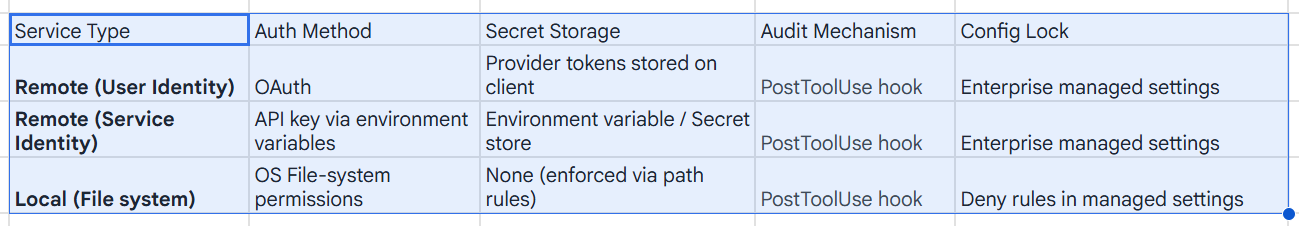

Python Code Example: Implementing an Audit Hook for Tool Usage
While the page focuses on theoretical architecture, logging tool execution deterministically via a Python hook or wrapper is standard practice for enterprise compliance:

In [ ]:
import logging

logging.basicConfig(level=logging.INFO)


def post_tool_use_hook(tool_name: str, tool_inputs: dict, tool_output: dict):
    """Deterministically logs every tool call execution to an audit store."""
    audit_record = {
        "event": "PostToolUse",
        "tool": tool_name,
        "inputs": tool_inputs,
        "output": tool_output,
    }
    # Log to audit store/system
    logging.info(f"AUDIT LOG: {audit_record}")


def execute_mcp_tool(tool_name: str, tool_inputs: dict, tool_func):
    """Executes an MCP tool call and guarantees audit logging."""
    # Execute the requested tool
    result = tool_func(**tool_inputs)

    # PostToolUse Hook fires deterministically for every call
    post_tool_use_hook(tool_name, tool_inputs, result)

    return result